In [1]:
!pip install numpy pillow matplotlib seaborn scikit-learn torch torchvision sympy mpmath

In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
DEVICE = "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [5]:
CKPLUS_ROOT = r"C:\Users\I N T E L\Desktop\FER_Evaluation\CK +"   
VGG_MODEL_PATH = r"C:\Users\I N T E L\Desktop\FER_Evaluation\FER_VGG19\best.pth"       
RESNET_MODEL_PATH = r"C:\Users\I N T E L\Desktop\FER_Evaluation\FER_ResNet18\best.pth" 

NUM_CLASSES = 7
BATCH_SIZE = 32
IMG_SIZE = 224

In [6]:
emotion_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

label_to_idx = {
    "anger": 0,
    "disgust": 1,
    "fear": 2,
    "joy": 3,
    "sadness": 4,
    "surprise": 5,
    "neutral": 6
}

folder_mapping = {
    "anger": "anger",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "joy",
    "happiness": "joy",
    "joy": "joy",
    "sadness": "sadness",
    "surprise": "surprise"
}

In [7]:
class CKPlusDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder)

            if not os.path.isdir(folder_path):
                continue

            folder_lower = folder.lower().strip()

            if folder_lower == "contempt":
                print("Skipping contempt class")
                continue

            if folder_lower not in folder_mapping:
                print(f"Skipping unknown folder: {folder}")
                continue

            mapped_label = folder_mapping[folder_lower]
            label_idx = label_to_idx[mapped_label]

            for fname in os.listdir(folder_path):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    img_path = os.path.join(folder_path, fname)
                    self.samples.append((img_path, label_idx))

        print(f"Loaded {len(self.samples)} CK+ images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [9]:
ck_dataset = CKPlusDataset(CKPLUS_ROOT, transform=eval_tf)
ck_loader = DataLoader(ck_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Number of CK+ samples:", len(ck_dataset))

Skipping contempt class
Loaded 927 CK+ images
Number of CK+ samples: 927


In [10]:
def get_model(name):
    if name == "VGG19":
        model = models.vgg19(weights=None)
        model.classifier[6] = nn.Linear(4096, NUM_CLASSES)

    elif name == "ResNet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    else:
        raise ValueError("Unknown model name")

    return model.to(DEVICE)

In [11]:
def load_trained_model(model_name, model_path):
    model = get_model(model_name)
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [12]:
def evaluate_model(model, loader, model_name):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"\n===== {model_name} on CK+ =====")
    print(f"Accuracy: {acc:.4f}\n")

    ck_class_names = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]

    print(classification_report(
        all_labels,
        all_preds,
        labels=[0,1,2,3,4,5],
        target_names=ck_class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3,4,5])

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=ck_class_names,
        yticklabels=ck_class_names
    )
    plt.title(f"{model_name} - CK+ Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, all_labels, all_preds

In [13]:
vgg_model = load_trained_model("VGG19", VGG_MODEL_PATH)
resnet_model = load_trained_model("ResNet18", RESNET_MODEL_PATH)

print("Both models loaded successfully.")

Both models loaded successfully.



===== VGG19 on CK+ =====
Accuracy: 0.6731

              precision    recall  f1-score   support

       anger     0.3510    0.6370    0.4526       135
     disgust     0.7879    0.1469    0.2476       177
        fear     0.6182    0.4533    0.5231        75
         joy     0.9079    1.0000    0.9517       207
     sadness     0.6180    0.6548    0.6358        84
    surprise     0.9643    0.8675    0.9133       249

   micro avg     0.7140    0.6731    0.6929       927
   macro avg     0.7079    0.6266    0.6207       927
weighted avg     0.7693    0.6731    0.6710       927



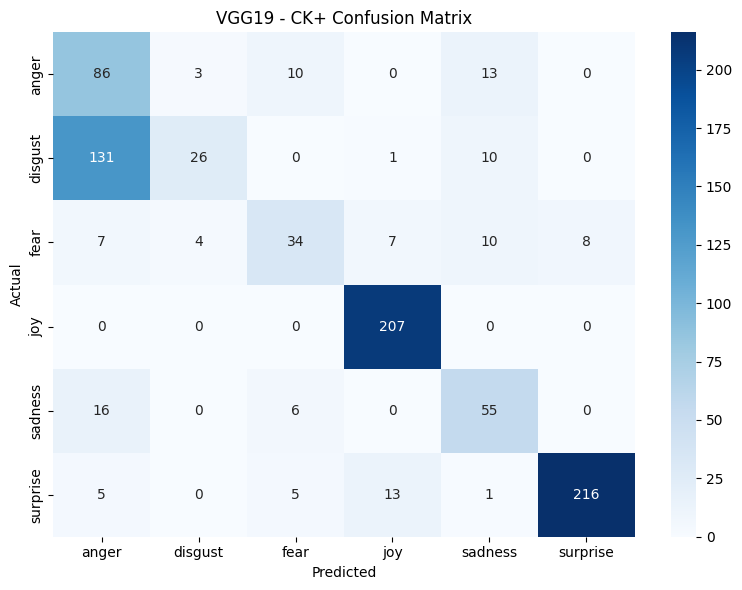

In [15]:
vgg_acc, vgg_labels, vgg_preds = evaluate_model(vgg_model, ck_loader, "VGG19")


===== ResNet18 on CK+ =====
Accuracy: 0.6375

              precision    recall  f1-score   support

       anger     0.3294    0.6222    0.4308       135
     disgust     0.8800    0.1243    0.2178       177
        fear     0.6250    0.3333    0.4348        75
         joy     0.9159    1.0000    0.9561       207
     sadness     0.4206    0.5357    0.4712        84
    surprise     0.9720    0.8353    0.8985       249

   micro avg     0.6817    0.6375    0.6589       927
   macro avg     0.6905    0.5752    0.5682       927
weighted avg     0.7703    0.6375    0.6370       927



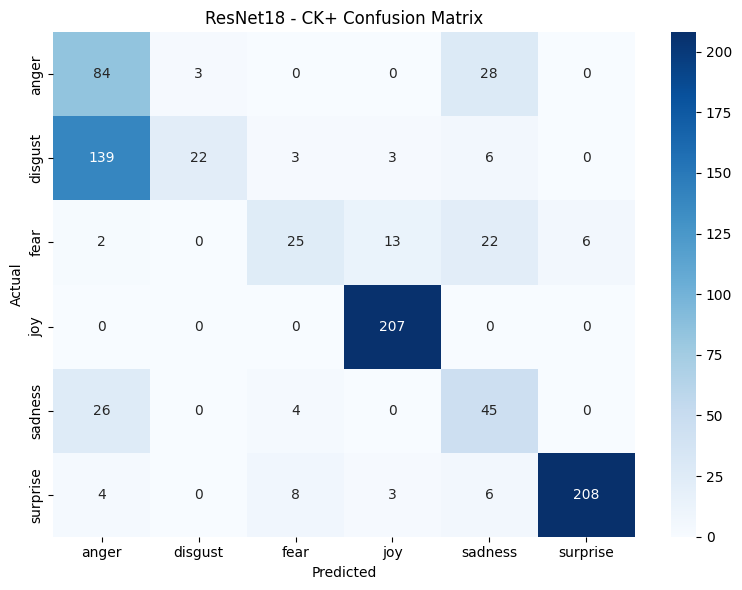

In [16]:
resnet_acc, resnet_labels, resnet_preds = evaluate_model(resnet_model, ck_loader, "ResNet18")

In [17]:
print("\n===== Final CK+ Comparison =====")
print(f"VGG19 Accuracy   : {vgg_acc:.4f}")
print(f"ResNet18 Accuracy: {resnet_acc:.4f}")

if vgg_acc > resnet_acc:
    print("VGG19 generalizes better on CK+")
elif resnet_acc > vgg_acc:
    print("ResNet18 generalizes better on CK+")
else:
    print("Both models perform equally on CK+")


===== Final CK+ Comparison =====
VGG19 Accuracy   : 0.6731
ResNet18 Accuracy: 0.6375
VGG19 generalizes better on CK+


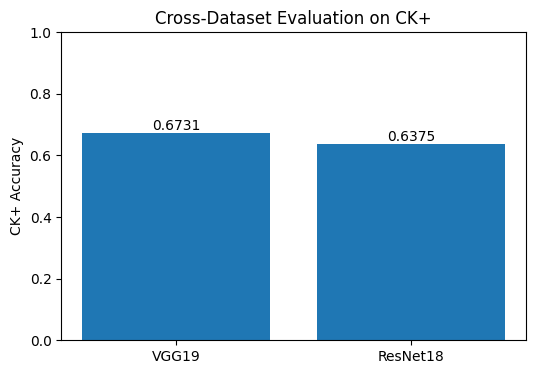

In [18]:
model_names = ["VGG19", "ResNet18"]
accuracies = [vgg_acc, resnet_acc]

plt.figure(figsize=(6,4))
bars = plt.bar(model_names, accuracies)
plt.ylabel("CK+ Accuracy")
plt.title("Cross-Dataset Evaluation on CK+")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.4f}", ha="center")

plt.ylim(0, 1)
plt.show()